# Quantum Teleportation

The No-Cloning Theorem states that it is impossible to make a quantum system which is a copy of another quantum system, as in there is no unitary $\hat U$ for which $\hat U |\psi \rangle|\phi\rangle = |\psi\rangle|\psi\rangle$. Intuitively this can be seen in how, while it may be possible given an unknown state to determine the magnitudes of each basis state to high precision through repeated measurement, it is impossible to get any information about the relative phase between them which is nontrivial information.  However, it is possible to take advantage of quantum entanglement to send information about the qubit using a classical channel such that the receiver, Bob, receives precisely the state that the sender Alice had, but no longer has.

Suppose Alice wants to send a qubit $|\psi\rangle$ to Bob. Prior to this Alice and Bob entangle a pair of qubits in the Bell state $|B_{00}\rangle$, each taking one. Then the three-qubit system begins in the initial state $|\psi\rangle\otimes|B_{00}\rangle$. From there Alice measures her two qubits in the Bell basis instead of the standard basis, recovering one of the four Bell states. Through some algebra we know that $|\psi\rangle\otimes|B_{00}\rangle = \frac{1}{2}[|B_{00}\rangle\otimes|\psi\rangle + |B_{01}\rangle\otimes\hat X |\psi\rangle + |B_{10}\rangle\otimes \hat Z |\psi\rangle + |B_{11}\rangle\otimes \hat X \hat Z |\psi\rangle]$, where for $|B_{ij}\rangle$ in the right-hand side $i$ denotes the message qubit and $j$ the entangled qubit. Thus, due to entanglement, Bob immediately recovers $|\psi\rangle$ up to a sequence of Pauli gates. Alice simply sends through a classical channel the two bits according to the Bell state she recovered, and from there Bob knows precisely the set of operators he needs to perform to recover $|\psi\rangle$ exactly.

In this notebook, I implemented the quantum teleportation with deferred measurement, performing the teleportation coherently and verifying by taking the partial trace of the final circuit to get Bob's state after the teleportation. Then by plotting on the Bloch sphere I could visually check that my initial state on Alice's qubit was indeed the same as the final state on Bob's qubit. In the future I could also do the full protocol with classical measurement. 

In [98]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
import numpy as np
from qiskit.visualization import plot_bloch_multivector

In [99]:
def build_quantum_teleporter(psi):
    assert isinstance(psi, Statevector)
    assert psi.num_qubits == 1
    qc = QuantumCircuit(3,2)
    qc.prepare_state(psi, 0)
    #entangle Alice and Bob qubits
    qc.h(1)
    qc.cx(1,2)
    #Alice's Bell measurement (rotate Bell basis to computational)
    qc.cx(0,1)
    qc.h(0)
    #Bob recovers state
    qc.cx(1,2)
    qc.cz(0,2)
    return qc

In [100]:
def teleport_state(psi):
    qc_teleport = build_quantum_teleporter(psi)
    state = Statevector(qc_teleport)
    bob_state = partial_trace(state, [0,1])
    return bob_state

## Testing

In [101]:
def get_random_psi():
    vec = np.random.randn(2) + 1j * np.random.randn(2)
    return Statevector(vec / np.linalg.norm(vec))

Alice's input state


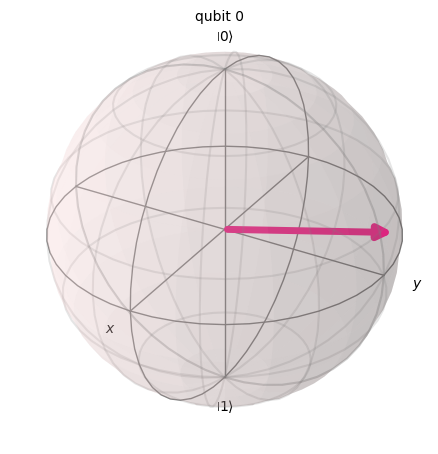

In [102]:
psi = get_random_psi()
print("Alice's input state")
plot_bloch_multivector(psi)

Bob's recovered state


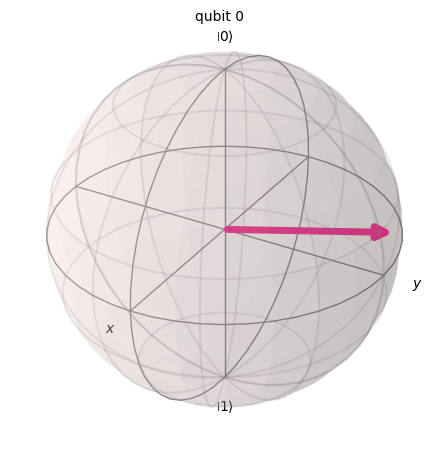

In [103]:
bob = teleport_state(psi)
print("Bob's recovered state")
plot_bloch_multivector(bob)

In [104]:
#fidelity - how close Alice's input and Bob's recovered states are
fid = state_fidelity(Statevector(psi), bob)
print(f"Fidelity: {fid:.6f}")
assert np.isclose(fid, 1.0), fid

Fidelity: 1.000000


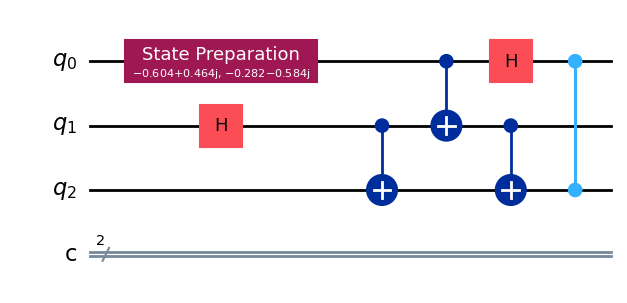

In [105]:
qc_draw = build_quantum_teleporter(psi)
qc_draw.draw('mpl')